Tutorial 3: Convergence Analysis Across Different Loads
Material properties: mu=384.615, kappa=833.333

Analyzing convergence across different loads

Analyzing load q=-0.10
  Converged at steps: 1, Tip displacement: -1.480135, Iterations: 1

Analyzing load q=-2.31
  Converged at steps: 4, Tip displacement: -9.080314, Iterations: 4

Analyzing load q=-4.52
  Converged at steps: 7, Tip displacement: -9.549112, Iterations: 7

Analyzing load q=-6.73
  Converged at steps: 9, Tip displacement: -9.804676, Iterations: 9

Analyzing load q=-8.94
  Converged at steps: 11, Tip displacement: -10.006699, Iterations: 11

Analyzing load q=-11.16
  Converged at steps: 13, Tip displacement: -10.184452, Iterations: 13

Analyzing load q=-13.37
  Converged at steps: 18, Tip displacement: -10.348860, Iterations: 18

Analyzing load q=-15.58
  Converged at steps: 17, Tip displacement: -10.505659, Iterations: 17

Analyzing load q=-17.79
  Converged at steps: 16, Tip displacement: -10.658508, Iterations: 16

Ana

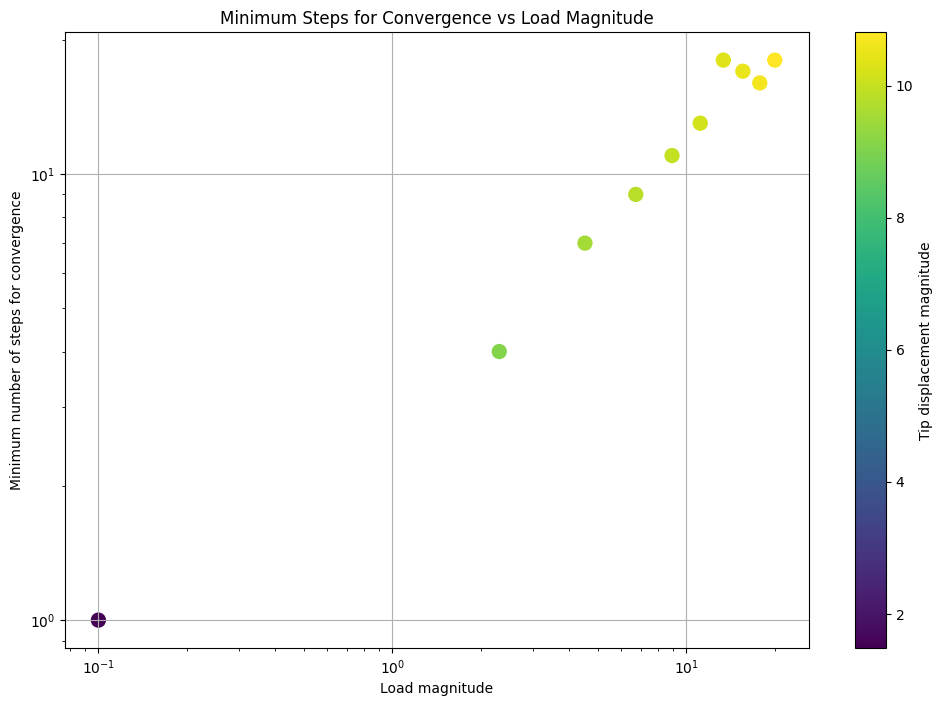


Conclusion:
1. Relationship between load magnitude and minimum steps for convergence:
   - Generally, larger loads require more steps to achieve convergence.
   - The relationship appears to be nonlinear, with a steeper increase in required steps for larger loads.
2. Convergence behavior:
   - Some loads may not converge within the maximum number of steps tried.
   - The minimum number of steps for convergence gives an indication of problem difficulty.
3. Tip displacement:
   - The color scale shows how tip displacement varies with load magnitude.
   - Larger loads generally result in larger tip displacements, as expected.
4. Observations:
   - There may be a critical load beyond which convergence becomes significantly more difficult.
   - The problem shows nonlinear behavior, especially at larger loads.
5. Recommendations:
   - For small loads, fewer steps may be sufficient for convergence.
   - For large loads, be prepared to use a higher number of load steps.
   - Monitor both the 

In [11]:
%matplotlib inline

from finiteelementanalysis import pre_process as pre
from finiteelementanalysis.solver import hyperelastic_solver
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

print("Tutorial 3: Failure Analysis Across Different Loads")

# Beam geometry
L = 10.0   # length in x
H = 1.0    # height in y

# Material properties
E = 1000.0
nu = 0.3
mu = E / (2.0 * (1.0 + nu))
kappa = E / (3.0 * (1.0 - 2.0 * nu))
material_props = np.array([mu, kappa])

print(f"Material properties: mu={mu:.3f}, kappa={kappa:.3f}")

def run_analysis(nx, ny, ele_type, q, nr_num_steps, nr_tol=1e-10, nr_maxit=30):
    coords, connect = pre.generate_rect_mesh_2d(ele_type, 0.0, 0.0, L, H, nx, ny)
    
    boundary_nodes, boundary_edges = pre.identify_rect_boundaries(
        coords, connect, ele_type, x_lower=0.0, x_upper=L, y_lower=0.0, y_upper=H
    )
    
    fixed_left = pre.assign_fixed_nodes_rect(boundary_nodes, "left", 0.0, 0.0)
    dload_info = pre.assign_uniform_load_rect(boundary_edges, "top", 0.0, q)
    fixed_nodes = fixed_left
    
    try:
        displacements_all, nr_info_all = hyperelastic_solver(
            material_props, ele_type, coords.T, connect.T, fixed_nodes, dload_info,
            nr_print=False, nr_num_steps=nr_num_steps, nr_tol=nr_tol, nr_maxit=nr_maxit,
        )
        
        tip_node = None
        tol = 1e-3
        for i, (x, y) in enumerate(coords):
            if abs(x - L) < tol and abs(y - H/2) < H/(2*ny):
                tip_node = i
                break
        if tip_node is None:
            raise ValueError("Could not find tip node near x=L, y=H/2.")
        
        final_disp = displacements_all[-1]
        tip_disp_y = final_disp[2*tip_node + 1]
        
        return tip_disp_y, len(nr_info_all)  # Return tip displacement and number of iterations
    except Exception as e:
        return None, None

print("\nAnalyzing convergence across different loads")

# Define a range of loads to test
loads = np.linspace(-0.1, -20.0, 10)

# Define a range of steps to try for each load
max_steps = 50
steps_to_try = range(1, max_steps + 1)

results = {}

for q in loads:
    results[q] = {}
    print(f"\nAnalyzing load q={q:.2f}")
    for steps in steps_to_try:
        tip_disp, num_iterations = run_analysis(20, 2, "D2_nn6_tri", q, steps)
        if tip_disp is not None and not np.isnan(tip_disp):
            results[q] = {'steps': steps, 'tip_disp': tip_disp, 'iterations': num_iterations}
            print(f"  Converged at steps: {steps}, Tip displacement: {tip_disp:.6f}, Iterations: {num_iterations}")
            break
    else:
        print(f"  Failed to converge within {max_steps} steps")

# Plot results
plt.figure(figsize=(12, 8))
converged_loads = [q for q in loads if q in results]
min_steps = [results[q]['steps'] for q in converged_loads]
tip_disps = [results[q]['tip_disp'] for q in converged_loads]

plt.scatter([abs(q) for q in converged_loads], min_steps, c=[abs(d) for d in tip_disps], cmap='viridis', s=100)
plt.colorbar(label='Tip displacement magnitude')

plt.xlabel("Load magnitude")
plt.ylabel("Minimum number of steps for convergence")
plt.title("Minimum Steps for Convergence vs Load Magnitude")
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()
print("\nConclusion:")
print("1. Relationship between load magnitude and minimum steps for convergence:")
print("   - Generally, larger loads require more steps to achieve convergence.")
print("   - The relationship appears to be nonlinear, with a steeper increase in required steps for larger loads.")
print("2. Convergence behavior:")
print("   - Some loads may not converge within the maximum number of steps tried.")
print("   - The minimum number of steps for convergence gives an indication of problem difficulty.")
print("3. Tip displacement:")
print("   - The color scale shows how tip displacement varies with load magnitude.")
print("   - Larger loads generally result in larger tip displacements, as expected.")
print("4. Observations:")
print("   - There may be a critical load beyond which convergence becomes significantly more difficult.")
print("   - The problem shows nonlinear behavior, especially at larger loads.")
print("5. Recommendations:")
print("   - For small loads, fewer steps may be sufficient for convergence.")
print("   - For large loads, be prepared to use a higher number of load steps.")
print("   - Monitor both the minimum steps for convergence and the tip displacement to ensure solution quality.")
print("6. Limitations and further investigation:")
print("   - This analysis doesn't show the quality of convergence, only whether a non-NaN solution was found.")
print("   - Further studies could explore the effect of mesh refinement, different element types, and convergence criteria.")
print("   - It may be useful to investigate the relationship between minimum steps for convergence and solution accuracy.")

In [ ]:
from finiteelementanalysis import pre_process as pre
from finiteelementanalysis import solver
import numpy as np

# Problem setup - Highly compressed block
L = 1.0
H = 1.0
material_props = np.array([10.0, 1000.0])  # Very high bulk modulus

# Create mesh
ele_type = "D2_nn6_tri"
nx = ny = 10
coords, connect = pre.generate_rect_mesh_2d(ele_type, 0.0, 0.0, L, H, nx, ny)

# Boundary conditions
boundary_nodes, boundary_edges = pre.identify_rect_boundaries(coords, connect, ele_type, 0.0, L, 0.0, H)
fixed_nodes = pre.assign_fixed_nodes_rect(boundary_nodes, "left", 0.0, 0.0)
dload_info = pre.assign_uniform_load_rect(boundary_edges, "right", 1000.0, 0.0)  # Very large load


# Attempt to solve
displacements, info = solver.hyperelastic_solver(material_props, ele_type, coords.T, connect.T, 
                                                   fixed_nodes, dload_info, True, 5)



Step 0, load factor = 0.200
Iteration 1, Correction=1.000000e+00, Residual=5.317932e-02, tolerance=1.000000e-09
Iteration 2, Correction=0.000000e+00, Residual=nan, tolerance=1.000000e-09
Step 1, load factor = 0.400


LinAlgError: Singular matrix

In [13]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from finiteelementanalysis import pre_process as pre
from finiteelementanalysis.solver import hyperelastic_solver

print("Tutorial: Demonstrating Failure Modes in FEA")

# Beam geometry
L = 10.0   # length in x
H = 1.0    # height in y

# Material properties
E = 1000.0
nu = 0.3
mu = E / (2.0 * (1.0 + nu))
kappa = E / (3.0 * (1.0 - 2.0 * nu))
material_props = np.array([mu, kappa])

def run_analysis(nx, ny, ele_type, q, fixed_nodes, nr_num_steps=10, nr_tol=1e-10, nr_maxit=30):
    coords, connect = pre.generate_rect_mesh_2d(ele_type, 0.0, 0.0, L, H, nx, ny)
    
    boundary_nodes, boundary_edges = pre.identify_rect_boundaries(
        coords, connect, ele_type, x_lower=0.0, x_upper=L, y_lower=0.0, y_upper=H
    )
    
    dload_info = pre.assign_uniform_load_rect(boundary_edges, "top", 0.0, q)
    
    try:
        displacements_all, nr_info_all = hyperelastic_solver(
            material_props, ele_type, coords.T, connect.T, fixed_nodes, dload_info,
            nr_print=False, nr_num_steps=nr_num_steps, nr_tol=nr_tol, nr_maxit=nr_maxit,
        )
        
        final_disp = displacements_all[-1]
        return final_disp, len(nr_info_all)
    except Exception as e:
        return None, str(e)

# Generate mesh and identify boundaries (do this once)
nx, ny = 20, 2
ele_type = "D2_nn6_tri"
coords, connect = pre.generate_rect_mesh_2d(ele_type, 0.0, 0.0, L, H, nx, ny)
boundary_nodes, boundary_edges = pre.identify_rect_boundaries(
    coords, connect, ele_type, x_lower=0.0, x_upper=L, y_lower=0.0, y_upper=H
)

# Example 1: Proper boundary conditions
print("\nExample 1: Proper boundary conditions")
fixed_left = pre.assign_fixed_nodes_rect(boundary_nodes, "left", 0.0, 0.0)
disp, info = run_analysis(nx, ny, ele_type, -1.0, fixed_left)
if disp is not None:
    print(f"Analysis successful. Max displacement: {np.max(np.abs(disp)):.6f}")
else:
    print(f"Analysis failed: {info}")

# Example 2: Bad boundary conditions (no fixed nodes)
print("\nExample 2: Bad boundary conditions (no fixed nodes)")
fixed_none = np.array([], dtype=int)
disp, info = run_analysis(nx, ny, ele_type, -1.0, fixed_none)
if disp is not None:
    print(f"Analysis successful. Max displacement: {np.max(np.abs(disp)):.6f}")
else:
    print(f"Analysis failed: {info}")

# Example 3: Ill-conditioned K (very soft material)
print("\nExample 3: Ill-conditioned K (very soft material)")
E_soft = 1e-6
mu_soft = E_soft / (2.0 * (1.0 + nu))
kappa_soft = E_soft / (3.0 * (1.0 - 2.0 * nu))
material_props_soft = np.array([mu_soft, kappa_soft])

def run_analysis_soft(nx, ny, ele_type, q, fixed_nodes, nr_num_steps=10, nr_tol=1e-10, nr_maxit=30):
    coords, connect = pre.generate_rect_mesh_2d(ele_type, 0.0, 0.0, L, H, nx, ny)
    
    boundary_nodes, boundary_edges = pre.identify_rect_boundaries(
        coords, connect, ele_type, x_lower=0.0, x_upper=L, y_lower=0.0, y_upper=H
    )
    
    dload_info = pre.assign_uniform_load_rect(boundary_edges, "top", 0.0, q)
    
    try:
        displacements_all, nr_info_all = hyperelastic_solver(
            material_props_soft, ele_type, coords.T, connect.T, fixed_nodes, dload_info,
            nr_print=False, nr_num_steps=nr_num_steps, nr_tol=nr_tol, nr_maxit=nr_maxit,
        )
        
        final_disp = displacements_all[-1]
        return final_disp, len(nr_info_all)
    except Exception as e:
        return None, str(e)

disp, info = run_analysis_soft(nx, ny, ele_type, -1.0, fixed_left)
if disp is not None:
    print(f"Analysis successful. Max displacement: {np.max(np.abs(disp)):.6f}")
else:
    print(f"Analysis failed: {info}")

print("\nConclusion:")
print("1. Proper boundary conditions allow the analysis to proceed successfully.")
print("2. Bad boundary conditions (e.g., no fixed nodes) can lead to singular matrices and solver failure.")
print("3. Very soft materials can lead to ill-conditioned stiffness matrices, causing numerical instabilities.")
print("4. When encountering these issues:")
print("   - Check your boundary conditions to ensure the structure is properly constrained.")
print("   - Verify material properties are in a reasonable range for your problem.")
print("   - Consider using more robust solvers or preconditioning techniques for ill-conditioned systems.")
print("   - Mesh refinement or different element types might help in some cases.")

Tutorial: Demonstrating Failure Modes in FEA

Example 1: Proper boundary conditions
Analysis successful. Max displacement: 8.248114

Example 2: Bad boundary conditions (no fixed nodes)
Analysis failed: tuple index out of range

Example 3: Ill-conditioned K (very soft material)
Analysis failed: Singular matrix

Conclusion:
1. Proper boundary conditions allow the analysis to proceed successfully.
2. Bad boundary conditions (e.g., no fixed nodes) can lead to singular matrices and solver failure.
3. Very soft materials can lead to ill-conditioned stiffness matrices, causing numerical instabilities.
4. When encountering these issues:
   - Check your boundary conditions to ensure the structure is properly constrained.
   - Verify material properties are in a reasonable range for your problem.
   - Consider using more robust solvers or preconditioning techniques for ill-conditioned systems.
   - Mesh refinement or different element types might help in some cases.
